In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [2]:
data = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')
display(data.head())
data.shape

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


(4572, 4)

In [3]:
missing_sales = data.Sales.isna().mean()
missing_sales = round(missing_sales*100, 2)
print("Porcentaje de promociones sin datos de ventas: " +  str(missing_sales) + '%')

Porcentaje de promociones sin datos de ventas: 0.13%


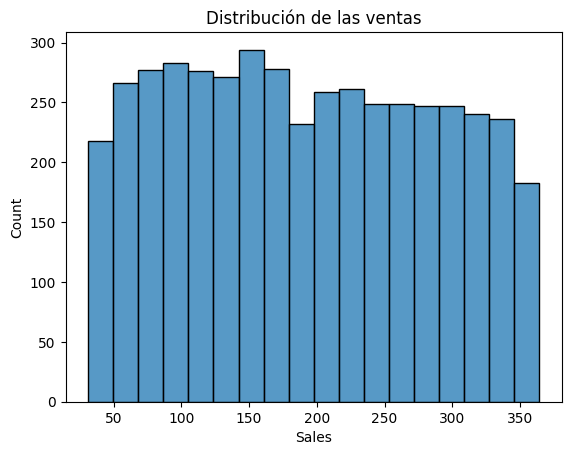

In [5]:

fig = sns.histplot(data['Sales'])
fig.set_title('Distribución de las ventas');

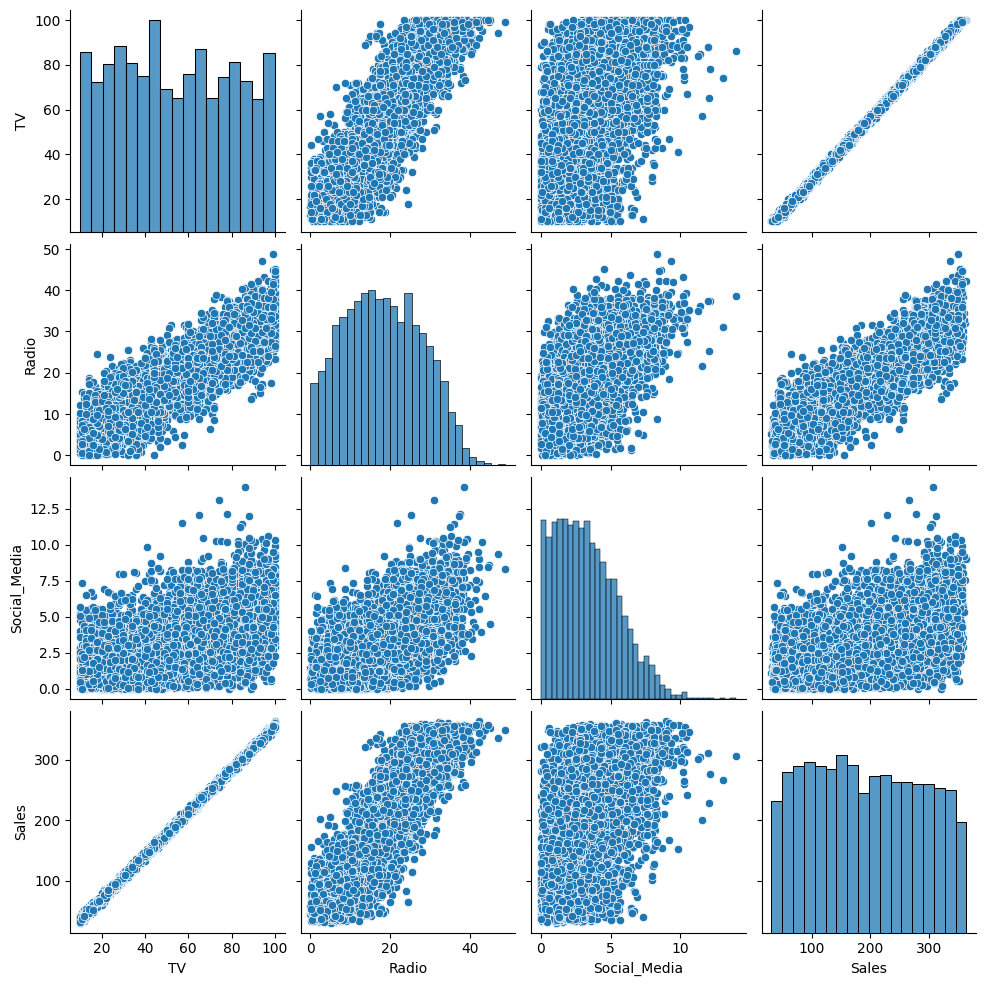

In [6]:
sns.pairplot(data)

In [16]:
ols_formula = 'Sales ~ TV'
OLS = ols(formula = ols_formula, data = data)
model = OLS.fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:43:14   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

<Axes: xlabel='TV', ylabel='Sales'>

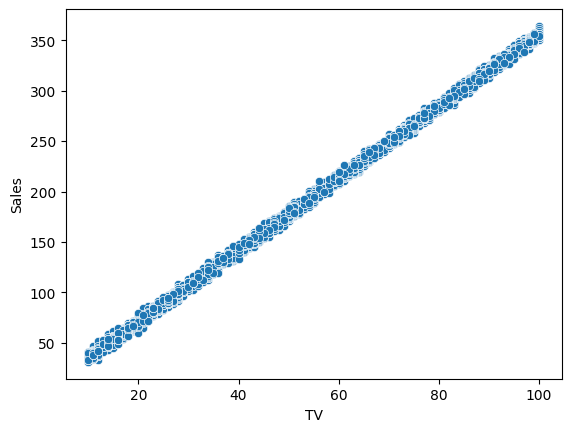

In [17]:
sns.scatterplot(x = data['TV'], y = data['Sales'])

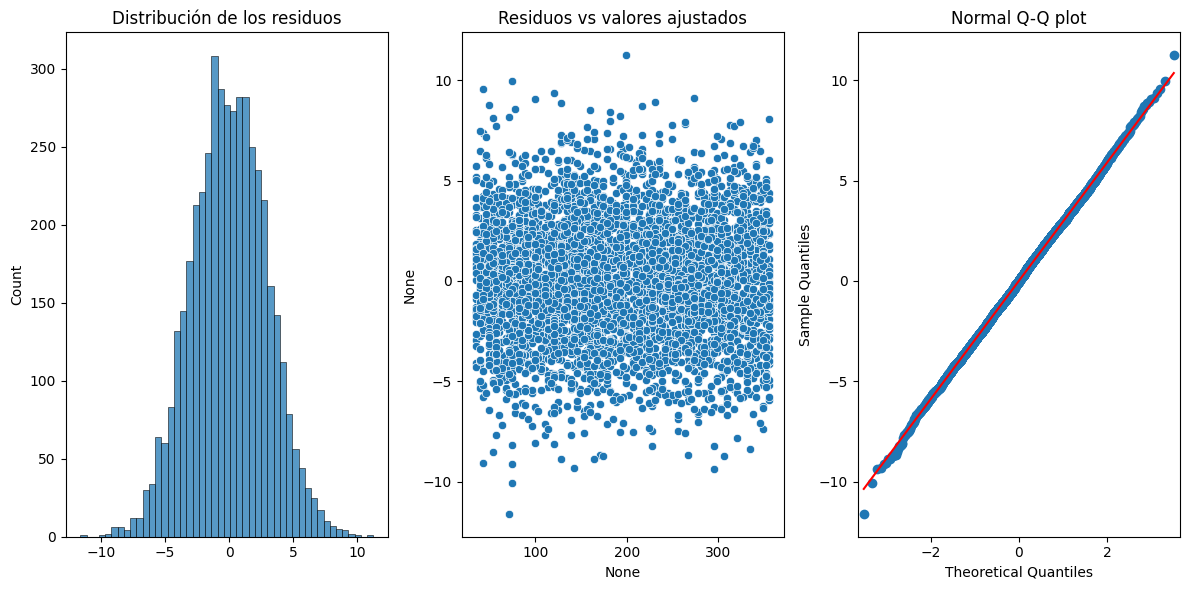

In [37]:
residuals = model.resid
fig, axes = plt.subplots(1, 3, figsize = (12, 6))
sns.histplot(residuals, ax = axes[0])
axes[0].set_title('Distribución de los residuos')
sns.scatterplot(x = model.fittedvalues, y = residuals, ax = axes[1])
axes[1].set_title('Residuos vs valores ajustados')
sm.qqplot(residuals, line='s',ax = axes[2])
axes[2].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.show()  

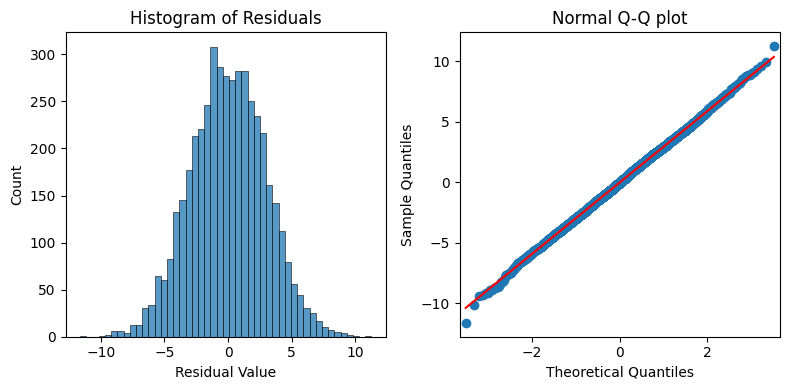

In [31]:
residuals = model.resid

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals .

### YOUR CODE HERE ### 

sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.

### YOUR CODE HERE ### 

sm.qqplot(residuals, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal Q-Q plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()


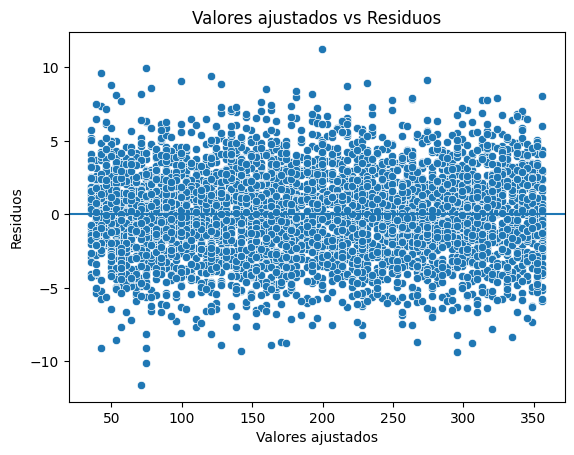

In [39]:
fig = sns.scatterplot(x = model.fittedvalues, y = model.resid)
fig.set_xlabel("Valores ajustados")
fig.set_ylabel("Residuos")
fig.set_title("Valores ajustados vs Residuos")
fig.axhline(0)

plt.show()

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:53:49   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
# Mostrar los intervalos de confianza al 99%
print("\nIntervalos de confianza al 99%:")
print(model.conf_int(alpha=0.01))


Intervalos de confianza al 99%:
                  0         1
Intercept -0.385305  0.132654
TV         3.557098  3.565724


In [43]:
# Obtener predicciones y sus intervalos de confianza al 99% para cada observación
pred = model.get_prediction(data)
pred_summary = pred.summary_frame(alpha=0.01)  # 99% de confianza
pred_summary.head()  # Mostramos solo las primeras filas

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,56.856252,0.077268,56.657139,57.055365,49.251049,64.461455
1,46.172019,0.081458,45.962108,46.381929,38.566525,53.777512
2,145.891529,0.048876,145.765579,146.017479,138.287889,153.495168
3,295.470794,0.065234,295.302691,295.638897,287.866340,303.075249
4,53.294841,0.078654,53.092156,53.497525,45.689543,60.900138


In [44]:
summary_dict = {
    'Coef.': model.params,
    'Std.Err.': model.bse,
    't': model.tvalues,
    'P>|t|': model.pvalues,
}
# Intervalos de confianza al 99%
conf_int_99 = model.conf_int(alpha=0.01)
summary_df = pd.DataFrame(summary_dict)
summary_df[['[0.005', '0.995]']] = conf_int_99

# Mostrar tabla
print('Métricas principales:')
print(f'R²: {model.rsquared:.4f}')
print(f'R² ajustado: {model.rsquared_adj:.4f}')
print(f'F-statistic: {model.fvalue:.2f}')
print(f'Prob (F-statistic): {model.f_pvalue:.4g}')
print(f'Log-Likelihood: {model.llf:.2f}')
print(f'AIC: {model.aic:.2f}')
print(f'BIC: {model.bic:.2f}\n')

print('Tabla de coeficientes con IC al 99%:')
display(summary_df)

Métricas principales:
R²: 0.9990
R² ajustado: 0.9990
F-statistic: 4527431.63
Prob (F-statistic): 0
Log-Likelihood: -11392.82
AIC: 22789.63
BIC: 22802.48

Tabla de coeficientes con IC al 99%:


,Coef.,Std.Err.,t,P>|t|,[0.005,0.995]
Intercept,-0.126325,0.100500,-1.256967,0.20883,-0.385305,0.132654
TV,3.561411,0.001674,2127.776216,0.00000,3.557098,3.565724
